##**Cel projektu i opis rozwiązania**

Celem projektu było opracowanie optymalnego systemu carpoolingu dla dwóch pojazdów, który pozwala zminimalizować łączny koszt przejazdów, przy jednoczesnym spełnieniu konkretnych opisanych poniżej.
Projekt ten został zrealizowany jako problem optymalizacyjny w środowisku Gurobi, z uwzględnieniem poniższych założeń i ograniczeń:

###**Założenia i cele modelu:**

 - Dwa pojazdy rozpoczynają i kończą trasę **w tych samych, wyznaczonych punktach** (depozyt początkowy i końcowy są stałe).

 - Każdy pojazd może przewieźć maksymalnie **czterech pasażerów**.

- Uwzględniono różne możliwe liczby pasażerów chętnych do skorzystania z przejazdu, co wymaga elastyczności modelu.

- Nie uwzględniano czasu pojawiania się zleceń – model zakłada, że wszystkie zapotrzebowania znane są z góry (**przed planowaniem trasy**).

- Celem jest **minimalizacja całkowitego kosztu przejazdów**, który zależy od odległości między punktami.

###**Model zawiera:**

- Ograniczenia zapewniające poprawny start i koniec tras,

- Ograniczenia przepływu (z każdego punktu wejście = wyjście),

- Limit liczby pasażerów dla każdego pojazdu,

- Przypisanie każdego pasażera do maksymalnie jednego pojazdu,

- Eliminację cykli (podtras) przy użyciu dodatkowych zmiennych t,

- Dostosowanie liczby obsługiwanych pasażerów w zależności od danych wejściowych,

In [2]:
!pip install gurobipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 29.2 MB/s eta 0:00:00


###Komentarz:

Macierz kosztów jest n na n, poniżej definiuję jej wielkość i zawartość .

V = 3 oznacza maksymalną pojemność auta równą 4.

In [110]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from gurobipy import Model

n = 13
V = 3
np.random.seed(1)
cost = np.random.randint(10, 50, size=(n, n)).astype(float)
np.fill_diagonal(cost, 100000)
# cost2 dodatkowe
np.random.seed(360)
cost2 = np.random.randint(15, 45, size=(n, n)).astype(float)
np.fill_diagonal(cost2, 100000)
# dla n=10
# start = 0
# koniec = 9
# pośrednie 1->8

In [111]:
print(cost)
print()
print(cost2)

[[1.0e+05 2.2e+01 1.8e+01 1.9e+01 2.1e+01 1.5e+01 2.5e+01 1.0e+01 2.6e+01
  1.1e+01 2.2e+01 1.7e+01 1.6e+01]
 [3.5e+01 1.0e+05 4.7e+01 2.8e+01 3.0e+01 2.1e+01 3.8e+01 3.9e+01 2.4e+01
  1.4e+01 3.3e+01 3.3e+01 4.0e+01]
 [4.2e+01 3.2e+01 1.0e+05 1.9e+01 1.7e+01 3.2e+01 1.1e+01 1.0e+01 2.7e+01
  1.8e+01 3.4e+01 2.3e+01 1.8e+01]
 [4.0e+01 1.7e+01 1.3e+01 1.0e+05 3.1e+01 1.3e+01 1.4e+01 3.4e+01 2.2e+01
  3.6e+01 2.6e+01 2.8e+01 2.5e+01]
 [1.0e+01 1.4e+01 3.5e+01 4.4e+01 1.0e+05 1.7e+01 3.6e+01 3.5e+01 3.2e+01
  1.9e+01 1.3e+01 4.9e+01 3.3e+01]
 [4.6e+01 3.7e+01 4.7e+01 2.9e+01 4.8e+01 1.0e+05 4.2e+01 4.4e+01 2.0e+01
  3.3e+01 2.5e+01 3.3e+01 3.5e+01]
 [1.7e+01 3.8e+01 2.0e+01 4.2e+01 3.4e+01 3.3e+01 1.0e+05 2.3e+01 1.3e+01
  1.0e+01 2.3e+01 1.6e+01 3.1e+01]
 [1.6e+01 1.2e+01 2.2e+01 3.7e+01 3.1e+01 2.1e+01 1.7e+01 1.0e+05 1.8e+01
  2.1e+01 2.2e+01 3.0e+01 4.0e+01]
 [4.6e+01 4.9e+01 1.7e+01 1.4e+01 2.8e+01 4.2e+01 2.3e+01 2.0e+01 1.0e+05
  2.7e+01 1.7e+01 3.4e+01 2.0e+01]
 [3.8e+01 3.0e+01 4

In [112]:
# Tworzenie modelu
model = Model("carpooling 1")
x = model.addVars(n, n, vtype=GRB.BINARY, name="x")
x2 = model.addVars(n, n, vtype=GRB.BINARY, name="x2")
t = model.addVars(n, vtype=GRB.INTEGER, name="t")
t2 = model.addVars(n, vtype=GRB.INTEGER, name="t")
# przypisanie klientów do aut n-2
y = model.addVars(2, n-2, vtype=GRB.BINARY, name="y")


-  y_{ik} – czy **klient** \( k \) jest przypisany do pojazdu \( i \),
-  t_i – kolejność odwiedzin przez **taksówkę 1** w punkcie \( i \),
-  t^{(2)}_i – kolejność odwiedzin przez **taksówkę 2** w punkcie \( i \),
-  F(X)  – funkcja kosztu przejazdów dla dwóch taksówek.
-  c_{ij}  — koszt przejazdu z punktu \( i \) do \( j \)
-  x_{ij}  — binarna zmienna: czy taksówka 1 jedzie z \( i \) do \( j \)
-  x^{(2)}_{ij}  — binarna zmienna: czy taksówka 2 jedzie z \( i \) do \( j \)

$$
\begin{aligned}
x_{ij} &\in \{0, 1\} && \text{czy taksówka 1 jedzie z } i \text{ do } j \\
x^{(2)}_{ij} &\in \{0, 1\} && \text{czy taksówka 2 jedzie z } i \text{ do } j \\
y_{ik} &\in \{0, 1\} && \text{czy klient } k \text{ jest przypisany do pojazdu } i \\
t_i &\in \mathbb{Z}_+ && \text{kolejność odwiedzin przez taksówkę 1 w punkcie } i \\
t^{(2)}_i &\in \mathbb{Z}_+ && \text{kolejność odwiedzin przez taksówkę 2 w punkcie } i
\end{aligned}
$$





$$
F(x) = \sum_{\substack{i = 0}}^{n - 1} \sum_{\substack{j = 0 \\ j \ne i}}^{n - 1} c_{ij} \cdot \left( x_{ij} + x^{(2)}_{ij} \right)
$$


In [113]:
model.setObjective(gp.quicksum(cost[i][j]*x2[i,j] + cost[i][j]*x[i,j]  for i in range(n) for j in range(n) if i != j), GRB.MINIMIZE)

$$
f(X^*) = \arg\min_{x \in X} F(x) = \arg\min_{x \in X} \sum_{i=0}^{n-1} \sum_{\substack{j=0 \\ j \ne i}}^{n-1} c_{ij} \cdot \left( x_{ij} + x^{(2)}_{ij} \right)
$$


In [ ]:
## wiersz to wejście kolumny to wyjście x[4, 8] i x[..., 9] ==0, suma(x[9, ...]) == 1
## suma(x[c, ...]) == 1, suma(x[..., c]) == 1  c = (od 1 do 8 ) i wejście i wyjścia mają
## x[..., 0] ==1, suma(x[0, ...]) == 0

In [114]:
# 2  wersja jakby taksówki działamy razem
for x_var, t_var in [(x,t), (x2, t2)]:

  # 6. 0: ma tylko wyjście
  model.addConstr(gp.quicksum(x_var[0,j] for j in range(n) if j != 0) == 1)
  model.addConstr(gp.quicksum(x_var[i,0] for i in range(n) if i != 0) == 0)

  # 7. Końcowy punkt (N8): ma tylko wejście
  model.addConstr(gp.quicksum(x_var[i,n-1] for i in range(n) if i != n-1) == 1)
  model.addConstr(gp.quicksum(x_var[n-1,j] for j in range(n) if j != n-1) == 0)

  # nie może być początek i od razu koniec i nie na odwrót
  model.addConstr(x_var[0,n-1] == 0)
  model.addConstr(x_var[n-1,0] == 0)

  # na diagonali nie może być 1 dla pewności, że to jest
  for i in range(n):
    model.addConstr(x_var[i, i] == 0)
        # Ograniczenie eliminacji subtur (kolejność odwiedzin)
  for i in range(0, n-1):
      for j in range(1, n):
          if i != j:
              model.addConstr(t_var[i] - t_var[j] + (n-1)*(x_var[i,j]) <= n-2)

    # Ograniczenia na zmienną t (kolejność) - 1 <= t[i] <= n-1
  for i in range(1, n-1):
      model.addConstr(t_var[i] >= 1)
      model.addConstr(t_var[i] <= n-1)

$$
\begin{aligned}
&\textbf{Start (punkt } 0\textbf{):} \\
&\sum_{\substack{j=0 \\ j \ne 0}}^{n-1} x_{0j} = 1, \quad \sum_{\substack{j=0 \\ j \ne 0}}^{n-1} x^{(2)}_{0j} = 1 \\
&\sum_{\substack{i=0 \\ i \ne 0}}^{n-1} x_{i0} = 0, \quad \sum_{\substack{i=0 \\ i \ne 0}}^{n-1} x^{(2)}_{i0} = 0 \\
\\
&\textbf{Koniec (punkt } n-1\textbf{):} \\
&\sum_{\substack{i=0 \\ i \ne n-1}}^{n-1} x_{i,n-1} = 1, \quad \sum_{\substack{i=0 \\ i \ne n-1}}^{n-1} x^{(2)}_{i,n-1} = 1 \\
&\sum_{\substack{j=0 \\ j \ne n-1}}^{n-1} x_{n-1,j} = 0, \quad \sum_{\substack{j=0 \\ j \ne n-1}}^{n-1} x^{(2)}_{n-1,j} = 0 \\
\\
&x_{0,n-1} = 0, \quad x^{(2)}_{0,n-1} = 0, \quad x_{n-1,0} = 0, \quad x^{(2)}_{n-1,0} = 0 \\
\\
&x_{ii} = 0, \quad x^{(2)}_{ii} = 0 \quad \forall i \in \{0, \dots, n-1\} \\
\\
&\textbf{Eliminacja subtur:} \\
&t_i - t_j + (n-1) \cdot x_{ij} \leq n - 2, \quad \forall i \ne j \\
&t^{(2)}_i - t^{(2)}_j + (n-1) \cdot x^{(2)}_{ij} \leq n - 2, \quad \forall i \ne j \\
&1 \leq t_i \leq n-1, \quad 1 \leq t^{(2)}_i \leq n-1, \quad \forall i \in \{1, \dots, n-2\}
\end{aligned}
$$



In [115]:
# ograniczeia dla y
# tylko jedene pasażer do jednego pojazu
for k in range(0, n-2):  # bez depozytu i ostatniego punktu
  model.addConstr((y[0,k] + y[1,k]) <= 1)

# ma być maksymalnie 4 pasażerów dla każdego auta jeśli się da tyle wziąć
if n-10+V <= 3:
  a = n-10+V
else:
  a = V
for i in range(2):
  # model.addConstr(gp.quicksum(y[i,k] for k in range(0, n-2)) == V) 10_>i wićej to 0 jakmnie to odejmuję jeden
  model.addConstr(gp.quicksum(y[i,k] for k in range(0, n-2)) >= a)

# #Ograniczenie, żeby obsłużyć wszystkich klientów
if n <= 10 and n-4>=0:
    b = n - 4  # tylu klientów trzeba obsłużyć
else:
    b = 6      # maksymalnie 8 klientów dla większych instancji

model.addConstr(gp.quicksum(y[i, k] for i in range(2) for k in range(n - 2)) == b)

<gurobi.Constr *Awaiting Model Update*>

$$
\begin{aligned}
&\textbf{Ograniczenia zmiennych przypisania pasazerow } y_{ik}: \\
\\
&\text{Kazdy pasażer przypisany do co najwyżej jednej taksowki:} \\
&\quad y_{0k} + y_{1k} \leq 1 \quad \forall k \in \{0, \dots, n-3\} \\
\\
&\text{Każda taksowka musi miec minimalnie } a \text{ pasażerów:} \\
&\quad \sum_{k=0}^{n-3} y_{ik} \geq a \quad \forall i \in \{0,1\} \\
\\
&\text{Lacznie obsluzonych musi byc dokładnie } b \text{ klientow:} \\
&\quad \sum_{i=0}^{1} \sum_{k=0}^{n-3} y_{ik} = b \\
\\
&\textbf{Wartosci dynamiczne:} \\
&\quad a = \begin{cases}
n - 10 + V & \text{jesli } n - 10 + V \leq 3 \\
V & \text{w przeciwnym razie}
\end{cases} \\
\\
&\quad b = \begin{cases}
n - 4 & \text{jesli } n \leq 10 \text{ i } n - 4 \geq 0 \\
6 & \text{w przeciwnym razie}
\end{cases}
\end{aligned}
$$


In [116]:
#suma z x po za startem i stoptem ma być równa ilości klientow wyznaczoną przez zmienną y
model.addConstr(gp.quicksum(x[k,j] for j in range(n) for k in range(n)) - 2
                      == gp.quicksum(y[0,k]for k in range(n-2)))
model.addConstr(gp.quicksum(x2[k,j] for j in range(n) for k in range(n)) - 2
                      == gp.quicksum(y[1,k]for k in range(n-2)))

# n-1 i 0 zero ma wejście(wiersz) n-1 ma wyjście.
# suma wierszy taka sama, suma kolumn taka sama z róznych zmiennych decyzjnych mniejsza równa 1
for k in range(1,n-1):
  model.addConstr((gp.quicksum(x[k,i] for i in range(1,n)) + gp.quicksum(x2[k,j] for j in range(1,n))) <= 1)
  model.addConstr((gp.quicksum(x[i,k] for i in range(0,n-1)) + gp.quicksum(x2[j,k] for j in range(0,n-1))) <= 1)
# suma gdy j==i dla tej samej zmiennej dec. gdy j to wiersz, a i to kol ma być równa
  model.addConstr(gp.quicksum(x[k,i] for i in range(1,n)) == gp.quicksum(x[j,k] for j in range(0,n-1)))
  model.addConstr(gp.quicksum(x2[k,i] for i in range(1,n)) == gp.quicksum(x2[j,k] for j in range(0,n-1)))

$$
\begin{aligned}
\textbf{Zaleznosc miedzy zmiennymi } x \text{ i } y: \\
&\sum_{k=0}^{n-1} \sum_{j=0}^{n-1} x_{kj} - 2 = \sum_{k=0}^{n-3} y_{0k} \\
&\sum_{k=0}^{n-1} \sum_{j=0}^{n-1} x^{(2)}_{kj} - 2 = \sum_{k=0}^{n-3} y_{1k} \\
\\
\textbf{Ograniczenia wejsc/wyjsc dla punktow } i \in \{1, \dots, n-2\}: \\
&\sum_{i=1}^{n-1} x_{ki} + \sum_{j=1}^{n-1} x^{(2)}_{kj} \leq 1 \quad \forall k \in \{1, \dots, n-2\} \\
&\sum_{i=0}^{n-2} x_{ik} + \sum_{j=0}^{n-2} x^{(2)}_{jk} \leq 1 \quad \forall k \in \{1, \dots, n-2\} \\
\\
\textbf{Zachowanie przeplywu (liczba wejsc = liczba wyjsc):} \\
&\sum_{i=1}^{n-1} x_{ki} = \sum_{j=0}^{n-2} x_{jk} \quad \forall k \in \{1, \dots, n-2\} \\
&\sum_{i=1}^{n-1} x^{(2)}_{ki} = \sum_{j=0}^{n-2} x^{(2)}_{jk} \quad \forall k \in \{1, \dots, n-2\}
\end{aligned}
$$




In [117]:
model.optimize()

Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 408 rows, 386 columns and 2406 nonzeros
Model fingerprint: 0x66fb5c8d
Variable types: 0 continuous, 386 integer (360 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [1e+01, 5e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+01]
Presolve removed 124 rows and 78 columns
Presolve time: 0.01s
Presolved: 284 rows, 308 columns, 1980 nonzeros
Variable types: 0 continuous, 308 integer (286 binary)

Root relaxation: objective 1.460000e+02, 62 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0  146.00000    0   20          -  146.000

In [118]:
optimal_values = [x[i,j].x for i in range(n) for j in range(n) if x[i,j].x == 1]
optimal_values_indeks = [(i,j) for i in range(n) for j in range(n) if x[i,j].x == 1]
print(optimal_values)
print(optimal_values_indeks)
optx = optimal_values
print()
optimal_values2 = [x2[i,j].x for i in range(n) for j in range(n) if x2[i,j].x == 1]
optimal_values_indeks2 = [(i,j) for i in range(n) for j in range(n) if x2[i,j].x == 1]
print(optimal_values2)
print(optimal_values_indeks2)
optx = optimal_values2

[1.0, 1.0, 1.0, 1.0, 1.0]
[(0, 7), (2, 12), (3, 2), (7, 8), (8, 3)]

[1.0, 1.0, 1.0, 1.0, 1.0]
[(0, 9), (4, 10), (5, 12), (9, 4), (10, 5)]


In [119]:
optimal_values = [x[i,j].x for i in range(n) for j in range(n)]
optimal_values = np.array(optimal_values).reshape(n,n)
print(optimal_values)
print()
optimal_values = [x2[i,j].x for i in range(n) for j in range(n)]
optimal_values = np.array(optimal_values).reshape(n,n)
print(optimal_values)

[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 

In [120]:
import matplotlib.pyplot as plt
import networkx as nx

def wyświetlanie_trasy(optimal_values_indeks_var):
  edges = optimal_values_indeks_var

  # Tworzymy graf
  G = nx.Graph()
  G.add_edges_from(edges)
  pos = nx.spring_layout(G, seed = 60)
  # Rysujemy węzły
  nx.draw(G, pos,  with_labels=True, node_size=700, node_color='skyblue')

  plt.title("Optimal Path dla aut")
  plt.show()


##Prezentacja Wyników

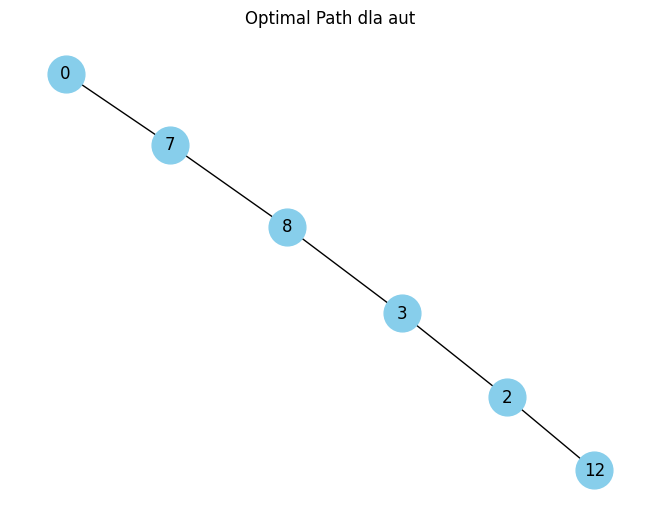

[-0.  1. 12. 11.  1. 12.  1.  1.  2.  1.  1. 12. 13.]


In [121]:
wyświetlanie_trasy(optimal_values_indeks)
t_values = [t[i].x for i in range(n)]
t_values = np.array(t_values)
print(t_values)

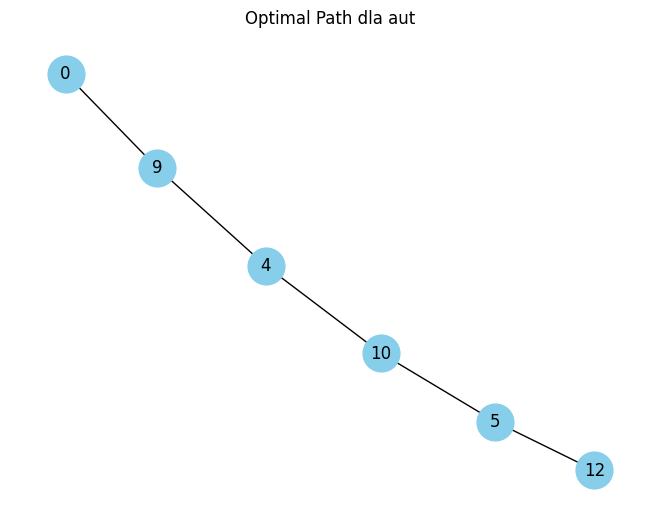

[-0.  1. 12. 12.  2.]


In [122]:
wyświetlanie_trasy(optimal_values_indeks2)
t_values2 = [t2[i].x for i in range(5)]
t_values2 = np.array(t_values2)
print(t_values2)

In [124]:
wynik = model.objVal
print("Wartość funckji celu: ",wynik)

Wartość funckji celu:  155.0


###Metaheurystyka Tabu Search

In [123]:
import numpy as np
import random

depot_start = 0
depot_end = n - 1

def uruchom_tabu_search(TABU_SIZE, MAX_ITER, c, seed1):
  # Funkcja licząca koszt rozwiązania (sumaryczna długość tras)
  def compute_cost(routes, cost_matrix):
      total = 0
      for route in routes:
          for i in range(len(route) - 1):
              total += cost_matrix[route[i]][route[i + 1]]
      return total

  # Generowanie sąsiadów przez zamianę punktów między trasami
  def generate_neighbors(solution):
      neighbors = []
      route1, route2 = solution
      for i in range(1, len(route1) - 1):
          for j in range(1, len(route2) - 1):
              new_route1 = route1.copy()
              new_route2 = route2.copy()
              new_route1[i], new_route2[j] = new_route2[j], new_route1[i]
              neighbors.append([new_route1, new_route2])
      return neighbors

  # Początkowe rozwiązanie: równy podział 6 klientów między 2 trasy
  clients = list(range(1, n - 1))  # pomijamy start=0 i koniec=9
  random.seed(seed1)
  selected_clients = random.sample(clients, c)  # wybierz ile klientów
  c = len(selected_clients)//2
  route1 = [depot_start] + selected_clients[:c] + [depot_end]
  route2 = [depot_start] + selected_clients[c:] + [depot_end]
  initial_solution = [route1, route2]

  # Tabu Search
  tabu_list = []
  current_solution = initial_solution
  best_solution = current_solution
  best_cost = compute_cost(current_solution, cost)

  for _ in range(MAX_ITER):
      neighbors = generate_neighbors(current_solution)
      neighbors = [n for n in neighbors if n not in tabu_list]

      if not neighbors:
          break

      current_solution = min(neighbors, key=lambda s: compute_cost(s, cost))
      current_cost = compute_cost(current_solution, cost)

      if current_cost < best_cost:
          best_cost = current_cost
          best_solution = current_solution

      tabu_list.append(current_solution)
      if len(tabu_list) > TABU_SIZE:
          tabu_list.pop(0)

  return best_solution, best_cost

##Główne elementy algorytmu:

###Reprezentacja rozwiązania:

Dwie listy (route1, route2) reprezentujące kolejność odwiedzin punktów przez każdą z taksówek (początek i koniec trasy są ustalone).

###Funkcja kosztu:

Oblicza sumaryczny koszt (długość tras) na podstawie macierzy kosztów cost.

###Sąsiedztwo:

Generowane przez zamianę jednego punktu trasy między pojazdami (swap klientów między route1 i route2).

###Lista tabu:

Zapamiętuje ostatnie rozwiązania, by uniknąć cyklicznego przeszukiwania tych samych rozwiązań (rozmiar sterowany przez TABU_SIZE).

##Wyniki i testy:

Przeprowadzono eksperymenty dla różnych parametrów (seed, TABU_SIZE, MAX_ITER) i **zapisywano najlepsze rozwiązanie**.

Wyświetlane są:

wartości seed, tabu_size, liczba iteracji

trasy obu taksówek

wartość funkcji celu

In [125]:
#ile minamalnie klientów bierze auto
if n<=10:
  ilość_klientów = n-2
else:
  ilość_klientów = 8

import pandas as pd
najlepsze = 10000000
for seeed in [10, 5, 15, 20, 25]:
  for tabu_size in [5, 10, 15, 25]:
      for max_iter in [50, 100, 150, 250]:
          best_solution, wynik = uruchom_tabu_search(tabu_size, max_iter, ilość_klientów, seeed)
          if wynik <= najlepsze:
              najlepsze = wynik
              print()
              print("Tabu size: ", tabu_size)
              print("seed: ", seeed)
              print("Liczba iteracji: ", max_iter)
              print("Taxi 1: ", best_solution[0])
              print("Taxi 2: ", best_solution[1])
              print("funkcja celu: ",wynik)
              print()


Tabu size:  5
seed:  10
Liczba iteracji:  50
Taxi 1:  [0, 7, 1, 8, 2, 12]
Taxi 2:  [0, 11, 4, 10, 5, 12]
funkcja celu:  178.0


Tabu size:  5
seed:  10
Liczba iteracji:  100
Taxi 1:  [0, 7, 1, 8, 2, 12]
Taxi 2:  [0, 11, 4, 10, 5, 12]
funkcja celu:  178.0


Tabu size:  5
seed:  10
Liczba iteracji:  150
Taxi 1:  [0, 7, 1, 8, 2, 12]
Taxi 2:  [0, 11, 4, 10, 5, 12]
funkcja celu:  178.0


Tabu size:  5
seed:  10
Liczba iteracji:  250
Taxi 1:  [0, 7, 1, 8, 2, 12]
Taxi 2:  [0, 11, 4, 10, 5, 12]
funkcja celu:  178.0


Tabu size:  10
seed:  10
Liczba iteracji:  50
Taxi 1:  [0, 7, 1, 8, 2, 12]
Taxi 2:  [0, 11, 4, 10, 5, 12]
funkcja celu:  178.0


Tabu size:  10
seed:  10
Liczba iteracji:  100
Taxi 1:  [0, 7, 1, 8, 2, 12]
Taxi 2:  [0, 11, 4, 10, 5, 12]
funkcja celu:  178.0


Tabu size:  10
seed:  10
Liczba iteracji:  150
Taxi 1:  [0, 7, 1, 8, 2, 12]
Taxi 2:  [0, 11, 4, 10, 5, 12]
funkcja celu:  178.0


Tabu size:  10
seed:  10
Liczba iteracji:  250
Taxi 1:  [0, 7, 1, 8, 2, 12]
Taxi 2:  [0, 11, 4,

##**Wnioski**:

Jeśli klientów jest względnie mało (do 10) to metaheurystyka radzi sobie nieżle, ma albo tak samo dobre wyniki, albo tylko minimalnie gorsze dla najlepszych prezentowanych wyników,
ale gdy macierz kosztów się robi większa to robią się **spore różnice**, model w gurobi jest dużo lepiej skalowalny.

Prawdopodobnie możliwe jest jeszcze ulepszenie metaheurystyki, ale dla naprawdę dużych macierzy to tych różnic **nie da się tak łatwo przysłonić**(dla n= 16 różnica 12). Im większa macierz kosztów to wartość funkcji celu ma lepsze wyniki dla modelu w gurobi, dla metaheurystyki też poprawia, ale mniej.

Zarówno tabu search jak i model w gurobi **spełnia założenia postawione na wstępie**, ale to zgodnie z oczekiwaniami model wylicza lepsze wyniki, istotne jednak dopiero dla dużych macierzy kosztów.